In [1]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score
import mlflow
import mlflow.sklearn
import pickle

In [2]:
df = pd.read_csv("../../data/crime_500k_cleaned.csv")

In [3]:
cat_columns = df.select_dtypes(include="object").columns
num_columns = df.select_dtypes(include=["int64","float64"]).columns
print(cat_columns)
print(num_columns)

Index(['Primary Type', 'Season'], dtype='object')
Index(['Arrest', 'Domestic', 'District', 'Community Area', 'Year', 'Latitude',
       'Longitude', 'Hour', 'Day', 'Day_of_Week', 'Month', 'Is_Weekend',
       'Crime_Severity_Score'],
      dtype='object')


In [4]:
X = df[["Longitude","Latitude"]]
X_sample = X.sample(n=10000, random_state=42)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

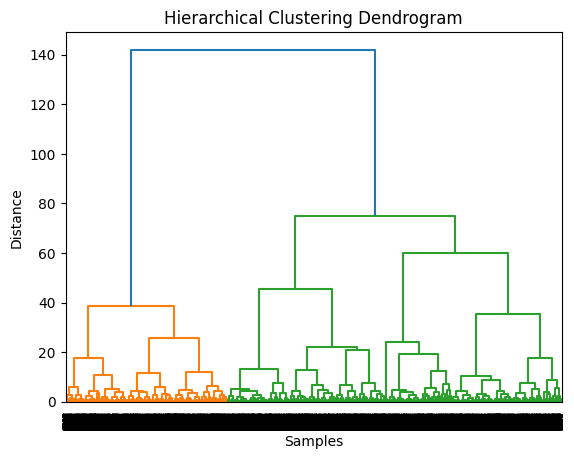

In [6]:
linked = linkage(X_scaled, method='ward')
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

In [7]:
clusters = 3
hc = AgglomerativeClustering(n_clusters=clusters, linkage="ward")
labels = hc.fit_predict(X_scaled)

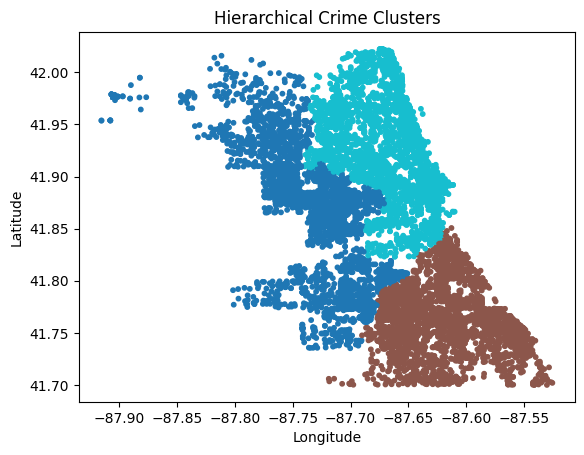

In [8]:
plt.scatter(
    X_sample["Longitude"],
    X_sample["Latitude"],
    c=labels,
    cmap="tab10",
    s=10
)

plt.title("Hierarchical Crime Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [9]:
silhouette_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", silhouette_score)

Silhouette Score: 0.38267625875033057


In [10]:
davies_bouldin_score = davies_bouldin_score(X_scaled, labels)
print(davies_bouldin_score)

1.0217275815443083


In [11]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Clustering")
with mlflow.start_run(run_name="Hierarchical"):
    mlflow.log_param("n_clusters", clusters)
    mlflow.log_metric("silhouette_score", silhouette_score)
    mlflow.log_metric("davies_bouldin_score", davies_bouldin_score)
    mlflow.sklearn.log_model(hc, "Hierarchical")

2026/03/11 15:30:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 15:30:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/11 15:30:03 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


🏃 View run Hierarchical at: http://127.0.0.1:5000/#/experiments/2/runs/d24d4df6fd2a48a482bde5fe85e9debc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [12]:
with open("../../models/hc.pkl", "wb") as f:
    pickle.dump(hc, f)